In [1]:
import numpy as np
import pandas as pd

In [2]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [3]:
r = np.full((20, 1000), fill_value=np.nan)

In [4]:
df = pd.read_csv('ratings_long.csv')

In [5]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [6]:
pd.DataFrame(r).iloc[:5, :20]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

# My Work

## 1. Quick Data Check

In [8]:
import matplotlib.pyplot as plt

R = r.copy()

print("Data shape:", df.shape)
print("Unique users:", df["userId"].nunique())
print("Unique rated movies:", df["movieId"].nunique())
print("Missing values in long data:")
print(df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Rating counts:")
print(df["rating"].value_counts().sort_index())

Data shape: (200, 3)
Unique users: 20
Unique rated movies: 179
Missing values in long data:
userId     0
movieId    0
rating     0
dtype: int64
Duplicate rows: 0
Rating counts:
rating
1    29
2    41
3    56
4    37
5    37
Name: count, dtype: int64


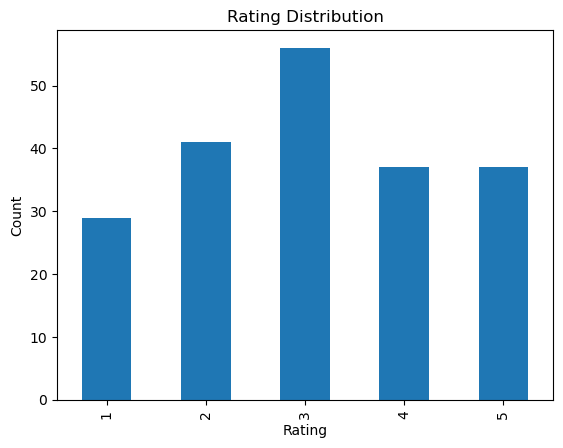

In [9]:
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

## 2. Sparsity

In [10]:
num_users, num_movies = R.shape
observed_count = np.sum(~np.isnan(R))
total_possible = num_users * num_movies
density = observed_count / total_possible
sparsity = 1 - density

print("Matrix shape:", R.shape)
print("Observed ratings:", observed_count)
print("Total possible ratings:", total_possible)
print("Density:", density)
print("Sparsity:", sparsity)

Matrix shape: (20, 1000)
Observed ratings: 200
Total possible ratings: 20000
Density: 0.01
Sparsity: 0.99


The matrix is very sparse. Training will use only observed ratings; missing cells are ignored.

## 3. Observed Rating Pairs

In [11]:
observed_positions = np.argwhere(~np.isnan(R))
observed_data = [
    (user_id, movie_id, R[user_id, movie_id])
    for user_id, movie_id in observed_positions
]

print("Number of observed datapoints:", len(observed_data))
print("First 10 observed positions:")
print(observed_positions[:10])

Number of observed datapoints: 200
First 10 observed positions:
[[  0  16]
 [  0  72]
 [  0  86]
 [  0 259]
 [  0 319]
 [  0 521]
 [  0 534]
 [  0 671]
 [  0 673]
 [  0 739]]


## 4. Matrix Factorization Model

We approximate the rating matrix as:

$R \approx U \times V$

The prediction for one user-movie pair is the dot product between one user vector and one movie vector.

In [12]:
from dataclasses import dataclass, field
from typing import Optional


@dataclass
class MatrixFactorizationGD:
    R: np.ndarray
    latent_dim: int = 4
    lr: float = 0.01
    reg: Optional[str] = "l2"       # None, "l1", "l2", or "elasticnet"
    reg_lambda: float = 0.001
    elastic_alpha: float = 0.5      # L1 ratio for ElasticNet
    seed: int = 42

    U: np.ndarray = field(init=False)
    V: np.ndarray = field(init=False)
    observed: list = field(init=False)

    def __post_init__(self):
        np.random.seed(self.seed)
        n_users, n_movies = self.R.shape

        self.U = np.random.normal(0, 0.1, size=(n_users, self.latent_dim))
        self.V = np.random.normal(0, 0.1, size=(self.latent_dim, n_movies))
        self.observed = self._get_observed_ratings()

    def _get_observed_ratings(self):
        positions = np.argwhere(~np.isnan(self.R))
        return [(i, j, self.R[i, j]) for i, j in positions]

    def predict(self, user_id, movie_id):
        return self.U[user_id] @ self.V[:, movie_id]

    def _regularization_value(self):
        if self.reg is None:
            return 0.0

        l1 = np.sum(np.abs(self.U)) + np.sum(np.abs(self.V))
        l2 = np.sum(self.U ** 2) + np.sum(self.V ** 2)
        n = len(self.observed)

        if self.reg == "l1":
            return self.reg_lambda * l1 / n
        if self.reg == "l2":
            return 0.5 * self.reg_lambda * l2 / n
        if self.reg == "elasticnet":
            return self.reg_lambda * (
                self.elastic_alpha * l1 + 0.5 * (1 - self.elastic_alpha) * l2
            ) / n

        raise ValueError("reg must be None, 'l1', 'l2', or 'elasticnet'")

    def mse(self):
        errors = []
        for user_id, movie_id, rating in self.observed:
            errors.append(self.predict(user_id, movie_id) - rating)
        errors = np.array(errors)
        return np.mean(errors ** 2)

    def mae(self):
        errors = []
        for user_id, movie_id, rating in self.observed:
            errors.append(self.predict(user_id, movie_id) - rating)
        errors = np.array(errors)
        return np.mean(np.abs(errors))

    def objective_loss(self):
        return 0.5 * self.mse() + self._regularization_value()

    def _regularization_gradients(self, u_vec, v_vec):
        grad_u = np.zeros_like(u_vec)
        grad_v = np.zeros_like(v_vec)
        n = len(self.observed)

        if self.reg is None:
            return grad_u, grad_v

        scale = self.reg_lambda / n

        if self.reg == "l2":
            grad_u += scale * u_vec
            grad_v += scale * v_vec

        elif self.reg == "l1":
            grad_u += scale * np.sign(u_vec)
            grad_v += scale * np.sign(v_vec)

        elif self.reg == "elasticnet":
            grad_u += scale * (
                self.elastic_alpha * np.sign(u_vec) + (1 - self.elastic_alpha) * u_vec
            )
            grad_v += scale * (
                self.elastic_alpha * np.sign(v_vec) + (1 - self.elastic_alpha) * v_vec
            )

        else:
            raise ValueError("reg must be None, 'l1', 'l2', or 'elasticnet'")

        return grad_u, grad_v

    def _update_one(self, user_id, movie_id, rating):
        u_old = self.U[user_id].copy()
        v_old = self.V[:, movie_id].copy()

        prediction = u_old @ v_old
        error = prediction - rating

        grad_u = error * v_old
        grad_v = error * u_old

        reg_grad_u, reg_grad_v = self._regularization_gradients(u_old, v_old)
        grad_u += reg_grad_u
        grad_v += reg_grad_v

        self.U[user_id] -= self.lr * grad_u
        self.V[:, movie_id] -= self.lr * grad_v

    def fit(self, epochs=1000, print_every=100, patience=50, min_delta=1e-6):
        losses = []
        best_loss = float("inf")
        wait = 0

        for epoch in range(epochs):
            np.random.shuffle(self.observed)

            for user_id, movie_id, rating in self.observed:
                self._update_one(user_id, movie_id, rating)

            loss = self.objective_loss()
            losses.append(loss)

            if epoch % print_every == 0:
                print(f"Epoch {epoch} | loss={loss:.6f} | mse={self.mse():.6f}")

            if best_loss - loss > min_delta:
                best_loss = loss
                wait = 0
            else:
                wait += 1

            if wait >= patience:
                print(f"Early stopped at epoch {epoch}")
                break

        return losses

    def sample_predictions(self, n=5):
        sample_indices = np.random.choice(len(self.observed), size=n, replace=False)
        rows = []

        for idx in sample_indices:
            user_id, movie_id, rating = self.observed[idx]
            raw_prediction = self.predict(user_id, movie_id)
            clipped_prediction = np.clip(raw_prediction, 1, 5)

            rows.append({
                "userId": user_id,
                "movieId": movie_id,
                "actual_rating": rating,
                "predicted_rating": round(raw_prediction, 3),
                "clipped_prediction": round(clipped_prediction, 3),
            })

        return pd.DataFrame(rows)

## 5. Train the Model

In [13]:
model = MatrixFactorizationGD(
    R=R,
    latent_dim=4,
    lr=0.01,
    reg="elasticnet",
    reg_lambda=0.001,
    elastic_alpha=0.5,
    seed=42,
)

losses = model.fit(
    epochs=1000,
    print_every=100,
    patience=50,
    min_delta=1e-6,
)

Epoch 0 | loss=5.527606 | mse=11.053489
Epoch 100 | loss=0.002288 | mse=0.000138
Epoch 200 | loss=0.002220 | mse=0.000002
Early stopped at epoch 246


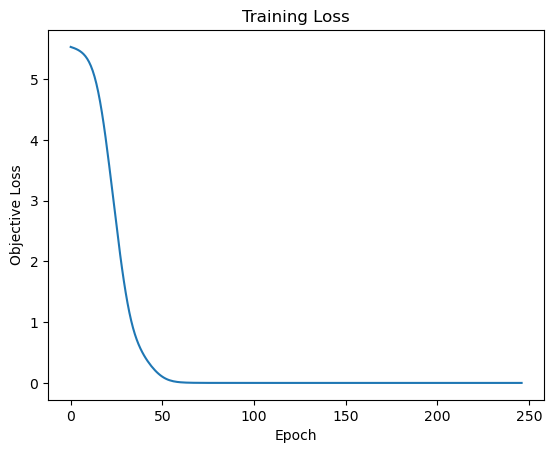

In [14]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Objective Loss")
plt.show()

## 6. Training Metrics

In [15]:
print("Final objective loss:", model.objective_loss())
print("Final MSE:", model.mse())
print("Final RMSE:", np.sqrt(model.mse()))
print("Final MAE:", model.mae())

Final objective loss: 0.0022197138977783416
Final MSE: 2.1082912168834554e-07
Final RMSE: 0.0004591613242514504
Final MAE: 8.939418070466665e-05


## 7. Example Predictions

In [16]:
model.sample_predictions(n=10)

,userId,movieId,actual_rating,predicted_rating,clipped_prediction
0,9,666,2.0,2.0,2.0
1,15,181,3.0,3.0,3.0
2,1,393,2.0,2.0,2.0
3,3,428,5.0,5.0,5.0
4,3,644,3.0,3.0,3.0
5,11,337,2.0,2.0,2.0
6,5,767,5.0,5.0,5.0
7,12,948,2.0,2.0,2.0
8,0,86,5.0,5.0,5.0
9,1,129,1.0,1.0,1.0


## 8. Small Regularization Check

In [17]:
results = []

for reg_name in [None, "l2", "elasticnet"]:
    temp_model = MatrixFactorizationGD(
        R=R,
        latent_dim=4,
        lr=0.01,
        reg=reg_name,
        reg_lambda=0.001,
        elastic_alpha=0.5,
        seed=42,
    )

    temp_losses = temp_model.fit(
        epochs=300,
        print_every=300,
        patience=40,
        min_delta=1e-6,
    )

    results.append({
        "regularization": str(reg_name),
        "final_loss": temp_losses[-1],
        "mse": temp_model.mse(),
        "rmse": np.sqrt(temp_model.mse()),
        "mae": temp_model.mae(),
    })

pd.DataFrame(results)

Epoch 0 | loss=5.526744 | mse=11.053489
Early stopped at epoch 233
Epoch 0 | loss=5.526846 | mse=11.053489
Early stopped at epoch 236
Epoch 0 | loss=5.527606 | mse=11.053489
Early stopped at epoch 236


,regularization,final_loss,mse,rmse,mae
0,None,1.853034e-07,3.706069e-07,0.000609,0.000116
1,l2,1.107605e-03,3.276663e-07,0.000572,0.000111
2,elasticnet,2.219770e-03,3.267000e-07,0.000572,0.000110


## Conclusion

The rating matrix is highly sparse: only 200 out of 20,000 possible ratings are observed.

I used matrix factorization and trained only on observed ratings. Missing ratings were ignored in the loss.

Regularization is included because the model has many parameters compared to the number of observed ratings.

Since this notebook trains on all observed ratings, the sample predictions show fit on known data. They are not a true generalization test. A larger dataset would be needed for reliable unseen-rating evaluation.